In [62]:
import requests
from IPython.core.display import HTML
# HTML(f"""
# <style>
# @import "https://cdn.jsdelivr.net/npm/bulma@0.9.4/css/bulma.min.css";
# </style>
# """)

# Line fitting the matrix way
This in-class exercise walks you through the following steps to fit a line to several datasets:
1. Create the datasets.
2. Construct design matrices.
3. Compute the weights using matrix inversion.
4. Plot the data and the fitted line.

## Linear (line) models

---
**Task 1 (easy): Identifying parameters👩‍💻**
1. Run the cell below to load the neccessary libraries and to construct the datasets.

2. Identify the inputs and the labels of each dataset. 



---

In [63]:
import numpy as np
import matplotlib.pyplot as plt

dataset_1 = np.array([[10, 2], [9, 6]])
dataset_2 = np.array([[5, 1], [7, 5]])
dataset_3 = np.array([[4, 2], [5, 3]])


---
**Task 2 (easy): Identifying parameters and constructing the design matrix👩‍💻**
1. Complete the `separate_inputs_labels`
 function below. The function should take a dataset as input and return the inputs and labels separated into separate variables. The function should return a matrix `X`
 containing the inputs and an array `y`
 containing the labels. Use the function to obtain the inputs and labels for each dataset.


**Hint**
Slicing might be helpful here.

2. Complete the code below and construct the design matrix for the other datasets. Print your results.


---

In [64]:
def separate_inputs_labels(dataset):
    """
    This function takes a dataset as input and returns the inputs and labels.
    
    Parameters:
    dataset (numpy array): The dataset to be separated.
    
    Returns:
    X (numpy array): The input matrix.
    y (numpy array): The labels array.
    """
    
    X = dataset[:, :-1]  # all rows, all columns except the last
    y = dataset[:, -1]   # all rows, only the last column
    # return the results as a tuple
    return X, y

# Applying the function to each dataset
X1, y1 = separate_inputs_labels(dataset_1)
X2, y2 = separate_inputs_labels(dataset_2)
X3, y3 = separate_inputs_labels(dataset_3)

def get_design_matrix(X):
    """
    This function takes an input matrix X and returns the design matrix by adding a column of ones.
    
    Parameters:
    X (numpy array): The input matrix.
    
    Returns:
    X_design (numpy array): The design matrix with the added column of ones.
    """
    n, m = X.shape  # get dimensions of X
    ones_column = np.ones((n, 1))  # create a column of ones with n rows and 1 column
    X_design = np.column_stack((X, ones_column))  # add a column of ones for the bias term
    return X_design

# construct the design matrix
X1_design = get_design_matrix(X1)
X2_design = get_design_matrix(X2)
X3_design = get_design_matrix(X3)
# Print the datasets
print("X1 = \n",X1)
print("y1 =", y1)
print("X2 = \n",X2)
print("y2 =", y2)
print("X3 = \n",X3)
print("y3 =", y3)
print("Design Matrix for Dataset 1:\n", X1_design)
print("Design Matrix for Dataset 2:\n", X2_design)
print("Design Matrix for Dataset 3:\n", X3_design)

X1 = 
 [[10]
 [ 9]]
y1 = [2 6]
X2 = 
 [[5]
 [7]]
y2 = [1 5]
X3 = 
 [[4]
 [5]]
y3 = [2 3]
Design Matrix for Dataset 1:
 [[10.  1.]
 [ 9.  1.]]
Design Matrix for Dataset 2:
 [[5. 1.]
 [7. 1.]]
Design Matrix for Dataset 3:
 [[4. 1.]
 [5. 1.]]



---
**Task 3 (easy): Solve for model parameters👩‍💻**
1. Find the inverse of the design matrix for each dataset constructed above.
2. Calculate the model weights, then print your results.
3. Use the `plot_model`
 function to plot your results.
4. Visually inspect the plots and interpret the meaning and influence of each term.


---

Inverse of Design Matrix for Dataset 1:
 [[ 1. -1.]
 [-9. 10.]]
Inverse of Design Matrix for Dataset 2:
 [[-0.5  0.5]
 [ 3.5 -2.5]]
Inverse of Design Matrix for Dataset 3:
 [[-1.  1.]
 [ 5. -4.]]
Weights for Dataset 1: [-4. 42.]
Weights for Dataset 2: [ 2. -9.]
Weights for Dataset 3: [ 1. -2.]


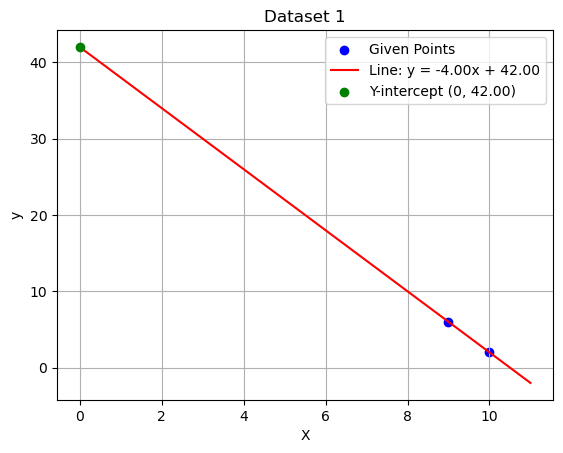

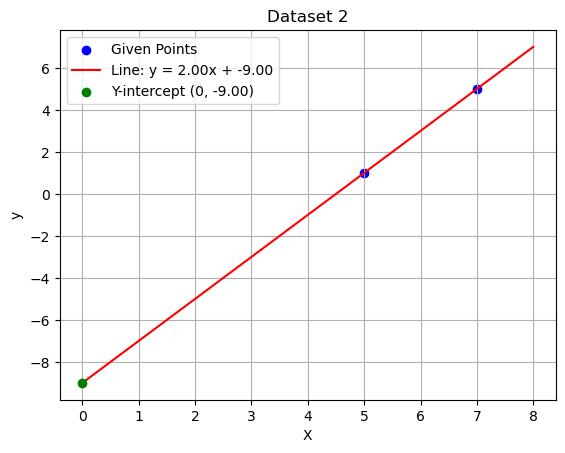

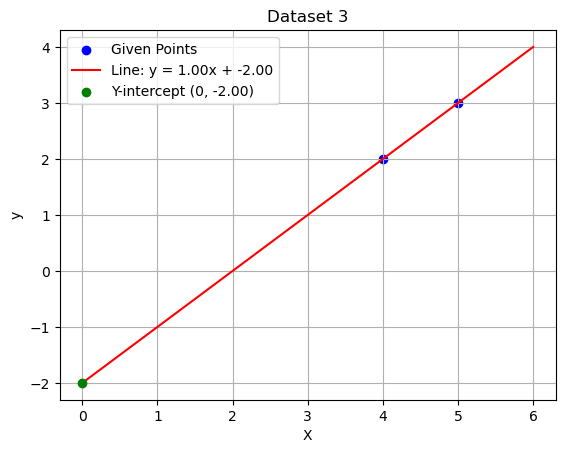

In [ ]:
invd1 = np.linalg.inv(X1_design)
invd2 = np.linalg.inv(X2_design)
invd3 = np.linalg.inv(X3_design)
print("Inverse of Design Matrix for Dataset 1:\n", invd1)
print("Inverse of Design Matrix for Dataset 2:\n", invd2)
print("Inverse of Design Matrix for Dataset 3:\n", invd3)

# We can compute the weights using the formula w = (A^T * A)^-1 * A^T * b:
# Since our design matrix is square (because we have exactly as many data points as parameters), we could actually just use the formula: w = A^-1 * b (if A is invertible)
# But for consistency, we'll use the general formula.

def compute_weights(X_design, y):
    weights = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
    return weights
weights1 = compute_weights(X1_design, y1)
weights2 = compute_weights(X2_design, y2)
weights3 = compute_weights(X3_design, y3)
print("Weights for Dataset 1:", weights1)
print("Weights for Dataset 2:", weights2)
print("Weights for Dataset 3:", weights3)

# Function to plot data points and fitted line
def plot_model(X, y, weights, dataset_name):
    # Plot the data points
    plt.scatter(X, y, color='blue', label='Given Points')
    
    # Extend x_vals range to include zero for correct y-intercept visualization
    x_vals = np.linspace(0, max(X) + 1, 100)
    y_vals = weights[0] * x_vals + weights[1]
    
    # Plot the fitted line
    plt.plot(x_vals, y_vals, color='red', label=f'Line: y = {weights[0]:.2f}x + {weights[1]:.2f}')
    
    # Plot the y-intercept
    plt.scatter(0, weights[1], color='green', zorder=5, label=f'Y-intercept (0, {weights[1]:.2f})')
    
    # Add title and labels
    plt.title(dataset_name)
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()
    

plot_model(X1, y1, weights1, 'Dataset 1')
plot_model(X2, y2, weights2, 'Dataset 2')
plot_model(X3, y3, weights3, 'Dataset 3')

If you have more time, complete the next task.

---
**Task 4 (easy): A new dataset👩‍💻♾️💡**
Run the cell below to define a new dataset.
1. Identify the inputs and the labels, then reuse the code from previous tasks to construct a design matrix.
2. Calculate the inverse of the design matrix. This step should result in an error. What are the possible reasons for getting this error?

**Note:** For pedagogical reasons, next week we will return to this dataset, as you will have the necessary tools to fit a model for this scenario.


---

In [66]:
dataset_4 = np.array([[9, 1], [7, 2],[3, 8], [1, 3],[4, 3]])